In [2]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 882.6 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/9.6 MB 882.6 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.6 MB 729.2 kB/s eta 0:00:13
   ------ --------------------------------- 1.6/9.6 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.6 MB 1.2 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.6 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.6 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/

In [4]:
%pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)

   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 0/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imblearn]

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE

In [7]:
# data =pd.read_csv("heart_attact_russia_youth_vs_adult.csv")
data = pd.read_csv("C:\\Users\\Sahib Chouhan\\OneDrive\\Desktop\\MACHINE LEARNING\\cardiovascular-risk-ml-models\\heart_attack_russia_youth_vs_adult.csv")


In [8]:
data.shape


(50000, 30)

In [9]:
data=data.sample(10000)

# Heart_Attack is my target variable.

In [10]:
data.head()

,ID,Age,Gender,Region,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Exercise_Level,Smoking,Alcohol_Consumption,Diabetes,Family_History,Stress_Level,Heart_Attack,Angina,Heart_Disease_History,Diet,Sleep_Hours,Occupation,Income_Level,Physical_Activity,Education_Level,Marital_Status,Urban_Rural,Medication,Health_Awareness,Daily_Water_Intake,Mental_Health,Obesity
41874,41875.0,26,Male,Suburban,110.5,199.6,25.5,79.0,High,False,NaN,False,True,10.0,True,False,False,Unhealthy,9.1,Unemployed,High,High,Secondary,Single,Urban,False,4.0,3.1,5.0,False
41668,41669.0,29,Female,Urban,140.4,171.0,28.4,76.0,Moderate,False,NaN,False,False,8.0,False,False,False,Mixed,4.5,Employed,Middle,Low,Primary,Single,Rural,True,1.0,2.3,9.0,False
18615,18616.0,57,Female,Urban,118.0,187.3,20.0,90.0,Moderate,False,NaN,True,False,1.0,False,False,False,Unhealthy,4.3,Unemployed,Low,Moderate,Secondary,Single,Urban,False,3.0,2.8,10.0,False
17940,17941.0,30,Female,Suburban,131.9,233.6,23.4,74.0,Moderate,False,Heavy,False,True,8.0,False,False,False,Unhealthy,8.0,Student,Middle,High,Primary,Married,Urban,False,5.0,2.9,10.0,False
9234,9235.0,28,Female,Rural,129.0,284.6,21.9,66.0,High,False,Moderate,True,True,5.0,False,True,False,Healthy,4.7,Employed,High,Moderate,Higher,Divorced,Urban,False,2.0,3.5,7.0,False


In [11]:
data.info() #no inconsistent data type 

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 41874 to 42849
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     9995 non-null   float64
 1   Age                    10000 non-null  int64  
 2   Gender                 10000 non-null  object 
 3   Region                 9996 non-null   object 
 4   Blood_Pressure         9997 non-null   float64
 5   Cholesterol            10000 non-null  float64
 6   BMI                    10000 non-null  float64
 7   Heart_Rate             9983 non-null   float64
 8   Exercise_Level         9970 non-null   object 
 9   Smoking                9980 non-null   object 
 10  Alcohol_Consumption    5039 non-null   object 
 11  Diabetes               9980 non-null   object 
 12  Family_History         9980 non-null   object 
 13  Stress_Level           9978 non-null   float64
 14  Heart_Attack           9980 non-null   object 
 15  Ang

# Checking redundant columns i.e. ID

In [12]:
data.drop("ID",axis=1,inplace=True)

In [13]:
data.shape

(10000, 29)

In [14]:
data.head(1)

,Age,Gender,Region,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Exercise_Level,Smoking,Alcohol_Consumption,Diabetes,Family_History,Stress_Level,Heart_Attack,Angina,Heart_Disease_History,Diet,Sleep_Hours,Occupation,Income_Level,Physical_Activity,Education_Level,Marital_Status,Urban_Rural,Medication,Health_Awareness,Daily_Water_Intake,Mental_Health,Obesity
41874,26,Male,Suburban,110.5,199.6,25.5,79.0,High,False,NaN,False,True,10.0,True,False,False,Unhealthy,9.1,Unemployed,High,High,Secondary,Single,Urban,False,4.0,3.1,5.0,False


# Checking duplicate rows 

In [15]:
data.duplicated()

41874    False
41668    False
18615    False
17940    False
9234     False
         ...  
11736    False
20135    False
8347     False
23676    False
42849    False
Length: 10000, dtype: bool

In [16]:
data[data.duplicated()]

,Age,Gender,Region,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Exercise_Level,Smoking,Alcohol_Consumption,Diabetes,Family_History,Stress_Level,Heart_Attack,Angina,Heart_Disease_History,Diet,Sleep_Hours,Occupation,Income_Level,Physical_Activity,Education_Level,Marital_Status,Urban_Rural,Medication,Health_Awareness,Daily_Water_Intake,Mental_Health,Obesity


# Checking null values 

In [17]:
data.shape

(10000, 29)

In [18]:
data.isnull().sum()/data.shape[0]*100

Age                       0.00
Gender                    0.00
Region                    0.04
Blood_Pressure            0.03
Cholesterol               0.00
BMI                       0.00
Heart_Rate                0.17
Exercise_Level            0.30
Smoking                   0.20
Alcohol_Consumption      49.61
Diabetes                  0.20
Family_History            0.20
Stress_Level              0.22
Heart_Attack              0.20
Angina                    0.31
Heart_Disease_History     0.11
Diet                      0.11
Sleep_Hours               0.11
Occupation                0.27
Income_Level              0.11
Physical_Activity         0.11
Education_Level           0.11
Marital_Status            0.15
Urban_Rural               0.14
Medication                0.10
Health_Awareness          0.10
Daily_Water_Intake        0.10
Mental_Health             0.10
Obesity                   0.00
dtype: float64

In [19]:
data.Heart_Attack.unique()

array([True, False, nan], dtype=object)

In [20]:
d = data[data["Heart_Attack"].isnull()==True].index

In [21]:
d

Index([267,  50,  52, 118, 122, 293,  76,  79,  98, 114,  48, 129,  78,  53,
       131,  45,  46, 113, 130, 295],
      dtype='int64')

In [22]:
data.drop(d,inplace=True)

# Filling null values 

In [23]:
data.isnull().sum()/data.shape[0]*100

Age                       0.000000
Gender                    0.000000
Region                    0.040080
Blood_Pressure            0.000000
Cholesterol               0.000000
BMI                       0.000000
Heart_Rate                0.000000
Exercise_Level            0.100200
Smoking                   0.000000
Alcohol_Consumption      49.509018
Diabetes                  0.000000
Family_History            0.000000
Stress_Level              0.020040
Heart_Attack              0.000000
Angina                    0.120240
Heart_Disease_History     0.000000
Diet                      0.000000
Sleep_Hours               0.000000
Occupation                0.150301
Income_Level              0.000000
Physical_Activity         0.000000
Education_Level           0.000000
Marital_Status            0.030060
Urban_Rural               0.030060
Medication                0.000000
Health_Awareness          0.000000
Daily_Water_Intake        0.000000
Mental_Health             0.000000
Obesity             

In [24]:
for i in data.select_dtypes(include="object"):
    data[i].fillna(data[i].mode()[0],inplace=True)

In [25]:
data.Alcohol_Consumption.mode()[0]

'Moderate'

In [26]:
for i in data.select_dtypes(exclude="object"):
    data[i].fillna(data[i].mean(),inplace=True)

In [27]:
data.isnull().sum()/data.shape[0]*100

Age                      0.0
Gender                   0.0
Region                   0.0
Blood_Pressure           0.0
Cholesterol              0.0
BMI                      0.0
Heart_Rate               0.0
Exercise_Level           0.0
Smoking                  0.0
Alcohol_Consumption      0.0
Diabetes                 0.0
Family_History           0.0
Stress_Level             0.0
Heart_Attack             0.0
Angina                   0.0
Heart_Disease_History    0.0
Diet                     0.0
Sleep_Hours              0.0
Occupation               0.0
Income_Level             0.0
Physical_Activity        0.0
Education_Level          0.0
Marital_Status           0.0
Urban_Rural              0.0
Medication               0.0
Health_Awareness         0.0
Daily_Water_Intake       0.0
Mental_Health            0.0
Obesity                  0.0
dtype: float64

In [28]:
data.Heart_Attack = data["Heart_Attack"].astype(np.number)

c:\Users\Sahib Chouhan\anaconda3\envs\ml_env\lib\site-packages\pandas\core\dtypes\common.py:1663: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


In [29]:
x=data.drop("Heart_Attack",axis=1)
y = data.Heart_Attack

In [30]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=13)

# Outlier treatment 

In [31]:
for i in xtrain.select_dtypes(include=np.number):
    q1=xtrain[i].quantile(0.25)
    q3=xtrain[i].quantile(0.75)
    iqr=q3-q1
    u=q3+1.5*iqr
    l=q1-1.5*iqr
    xtrain[i]=xtrain[i].clip(lower=l,upper=u)

In [32]:
for i in xtrain.select_dtypes(include="object"):
    print(i)
    print(xtrain[i].unique())

Gender
['Male' 'Female' 'Other']
Region
['Suburban' 'Urban' 'Rural']
Exercise_Level
['High' 'Low' 'Moderate']
Smoking
[True False]
Alcohol_Consumption
['Moderate' 'Heavy']
Diabetes
[False True]
Family_History
[False True]
Heart_Disease_History
[False True]
Diet
['Unhealthy' 'Mixed' 'Healthy']
Occupation
['Unemployed' 'Employed' 'Retired' 'Student']
Income_Level
['High' 'Low' 'Middle']
Physical_Activity
['Low' 'Moderate' 'High']
Education_Level
['Secondary' 'Higher' 'Primary']
Marital_Status
['Married' 'Single' 'Divorced' 'Widowed']
Urban_Rural
['Urban' 'Rural']
Medication
[False True]
Obesity
[True False]


## excersie level , alochol consuption , income level , physical activity ,diet 
## education level --- has ordinal data 

In [33]:
ordrinal_data = ["Physical_Activity","Income_Level","Exercise_Level"]

In [34]:
for i in ordrinal_data:
    xtest[i]=xtest[i].apply(lambda x: 3 if x=="High"  else  1 if x=="Low"  else 2)
    xtrain[i]=xtrain[i].apply(lambda x: 3 if x=="High"  else  1 if x=="Low"  else 2)
    

In [35]:
for i in ordrinal_data:
    print(i,xtrain[i].unique(),xtest[i].unique())

Physical_Activity [1 2 3] [2 1 3]
Income_Level [3 1 2] [2 1 3]
Exercise_Level [3 1 2] [3 2 1]


In [36]:
xtest["Diet"]=xtest["Diet"].apply(lambda x: 3 if x=='Healthy'  else  1 if x=='Unhealthy'  else 2)
xtrain["Diet"]=xtrain["Diet"].apply(lambda x: 3 if x=='Healthy'  else  1 if x=='Unhealthy'  else 2)
xtrain["Diet"].unique(),xtest["Diet"].unique()    

(array([1, 2, 3]), array([2, 3, 1]))

In [37]:
xtest["Alcohol_Consumption"]=xtest["Alcohol_Consumption"].apply(lambda x: 3 if x=='Heavy'  else  2)
xtrain["Alcohol_Consumption"]=xtrain["Alcohol_Consumption"].apply(lambda x: 3 if x=='Heavy'  else   2)
xtrain["Alcohol_Consumption"].unique(),xtest["Alcohol_Consumption"].unique()    

(array([2, 3]), array([2, 3]))

In [38]:
for i in xtrain.select_dtypes(include="object"):
    print(i)
    print(xtrain[i].unique())

Gender
['Male' 'Female' 'Other']
Region
['Suburban' 'Urban' 'Rural']
Smoking
[True False]
Diabetes
[False True]
Family_History
[False True]
Heart_Disease_History
[False True]
Occupation
['Unemployed' 'Employed' 'Retired' 'Student']
Education_Level
['Secondary' 'Higher' 'Primary']
Marital_Status
['Married' 'Single' 'Divorced' 'Widowed']
Urban_Rural
['Urban' 'Rural']
Medication
[False True]
Obesity
[True False]


In [39]:
nomial_1= ["Obesity","Smoking","Diabetes","Family_History","Angina","Heart_Disease_History","Medication"]

In [40]:
for i in nomial_1:
    xtrain[i]=xtrain[i].astype(np.int64)
    xtest[i]=xtest[i].astype(np.int64)
    print(i, xtrain[i].unique(),xtest[i].unique())

Obesity [1 0] [0 1]
Smoking [1 0] [1 0]
Diabetes [0 1] [0 1]
Family_History [0 1] [1 0]
Angina [0 1] [0 1]
Heart_Disease_History [0 1] [0 1]
Medication [0 1] [0 1]


In [41]:
Onehot_dummy=[]

In [42]:
for i in xtrain.select_dtypes(include="object"):
    print(i)
    print(xtrain[i].unique())
    Onehot_dummy.append(i)

Gender
['Male' 'Female' 'Other']
Region
['Suburban' 'Urban' 'Rural']
Occupation
['Unemployed' 'Employed' 'Retired' 'Student']
Education_Level
['Secondary' 'Higher' 'Primary']
Marital_Status
['Married' 'Single' 'Divorced' 'Widowed']
Urban_Rural
['Urban' 'Rural']


In [43]:
Onehot_dummy.pop()

'Urban_Rural'

In [44]:
Onehot_dummy

['Gender', 'Region', 'Occupation', 'Education_Level', 'Marital_Status']

In [45]:
for i in Onehot_dummy:
    xtrain = pd.concat([xtrain,pd.get_dummies(xtrain[i]).astype(np.int64)],axis=1)
    xtrain.drop(i,axis=1,inplace=True)
    xtest = pd.concat([xtest,pd.get_dummies(xtest[i]).astype(np.int64)],axis=1)
    xtest.drop(i,axis=1,inplace=True)
    print(xtrain.shape,xtest.shape)

(7984, 30) (1996, 30)
(7984, 32) (1996, 32)
(7984, 35) (1996, 35)
(7984, 37) (1996, 37)
(7984, 40) (1996, 40)


In [46]:
xtrain

,Age,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Exercise_Level,Smoking,Alcohol_Consumption,Diabetes,Family_History,Stress_Level,Angina,Heart_Disease_History,Diet,Sleep_Hours,Income_Level,Physical_Activity,Urban_Rural,Medication,Health_Awareness,Daily_Water_Intake,Mental_Health,Obesity,Female,Male,Other,Rural,Suburban,Urban,Employed,Retired,Student,Unemployed,Higher,Primary,Secondary,Divorced,Married,Single,Widowed
8818,48,128.5,273.4,18.80,64.0,3,1,2,0,0,8.0,0,0,1,6.6,3,1,Urban,0,4.0,1.2,5.0,1,0,1,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0
13739,26,105.8,90.6,14.10,76.0,1,0,2,0,0,9.0,1,0,2,5.2,3,2,Urban,0,3.0,4.7,8.0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0
5290,23,112.0,275.9,25.90,79.0,2,0,2,0,0,10.0,0,0,3,8.2,1,3,Rural,0,3.0,3.7,10.0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0
38879,53,103.8,211.7,30.10,74.0,2,1,2,0,1,8.0,0,0,2,7.1,1,3,Urban,0,4.0,3.9,7.0,1,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0
45637,50,134.7,218.1,29.50,90.0,2,0,2,0,0,6.0,0,0,2,7.0,1,2,Rural,1,1.0,3.6,4.0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44811,59,99.2,261.8,21.20,92.0,3,0,2,0,0,3.0,0,0,2,6.6,2,2,Rural,0,3.0,2.1,7.0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0
27945,36,119.7,118.0,31.10,79.0,2,0,2,0,1,10.0,0,0,1,6.3,1,2,Rural,1,4.0,2.3,3.0,0,0,0,1,0,0,1,0,0,0,1,1,0,0,0,1,0,0
32313,59,109.2,233.3,26.40,82.0,1,0,2,0,0,3.0,0,0,3,4.3,1,2,Rural,0,5.0,2.1,7.0,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0
47235,35,116.5,215.6,11.55,83.0,2,0,2,0,0,5.0,1,0,1,8.0,1,1,Urban,0,3.0,2.2,2.0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0


In [47]:
xtest["Urban_Rural"]=xtest["Urban_Rural"].apply(lambda x:0  if x=='Rural'  else   1)
xtrain["Urban_Rural"]=xtrain["Urban_Rural"].apply(lambda x:0  if x=='Rural'  else   1)
xtrain["Urban_Rural"].unique(),xtest["Urban_Rural"].unique()    

(array([1, 0]), array([1, 0]))

In [48]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7984 entries, 8818 to 2732
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    7984 non-null   int64  
 1   Blood_Pressure         7984 non-null   float64
 2   Cholesterol            7984 non-null   float64
 3   BMI                    7984 non-null   float64
 4   Heart_Rate             7984 non-null   float64
 5   Exercise_Level         7984 non-null   int64  
 6   Smoking                7984 non-null   int64  
 7   Alcohol_Consumption    7984 non-null   int64  
 8   Diabetes               7984 non-null   int64  
 9   Family_History         7984 non-null   int64  
 10  Stress_Level           7984 non-null   float64
 11  Angina                 7984 non-null   int64  
 12  Heart_Disease_History  7984 non-null   int64  
 13  Diet                   7984 non-null   int64  
 14  Sleep_Hours            7984 non-null   float64
 15  Income

In [49]:
xtest.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 8133 to 5348
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1996 non-null   int64  
 1   Blood_Pressure         1996 non-null   float64
 2   Cholesterol            1996 non-null   float64
 3   BMI                    1996 non-null   float64
 4   Heart_Rate             1996 non-null   float64
 5   Exercise_Level         1996 non-null   int64  
 6   Smoking                1996 non-null   int64  
 7   Alcohol_Consumption    1996 non-null   int64  
 8   Diabetes               1996 non-null   int64  
 9   Family_History         1996 non-null   int64  
 10  Stress_Level           1996 non-null   float64
 11  Angina                 1996 non-null   int64  
 12  Heart_Disease_History  1996 non-null   int64  
 13  Diet                   1996 non-null   int64  
 14  Sleep_Hours            1996 non-null   float64
 15  Income

# EDA

In [50]:
data["Heart_Attack"].value_counts(normalize=True)*100


Heart_Attack
0.0    88.066132
1.0    11.933868
Name: proportion, dtype: float64

<Axes: xlabel='Heart_Attack'>

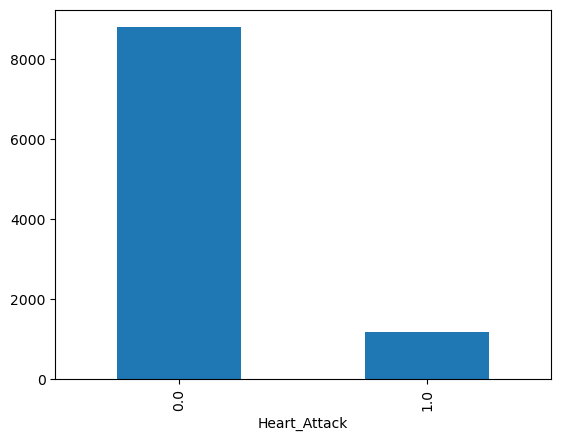

In [51]:
data["Heart_Attack"].value_counts().plot(kind="bar")

Age


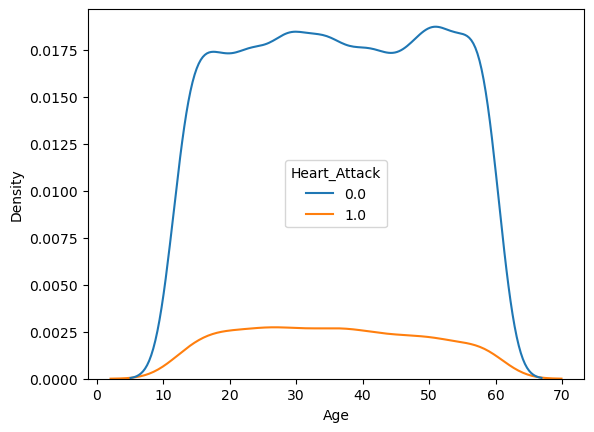

Blood_Pressure


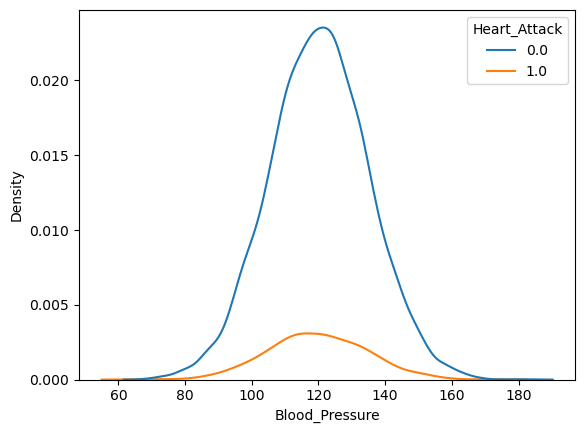

Cholesterol


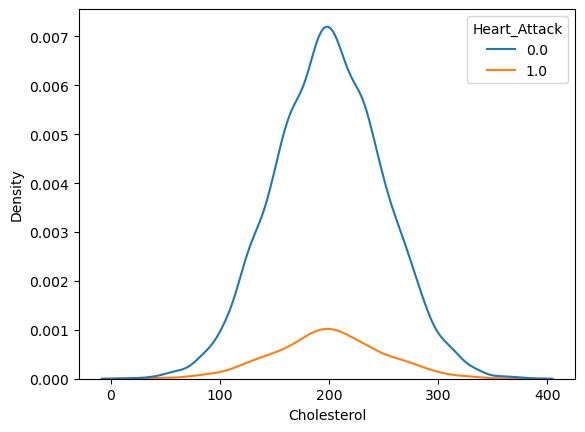

BMI


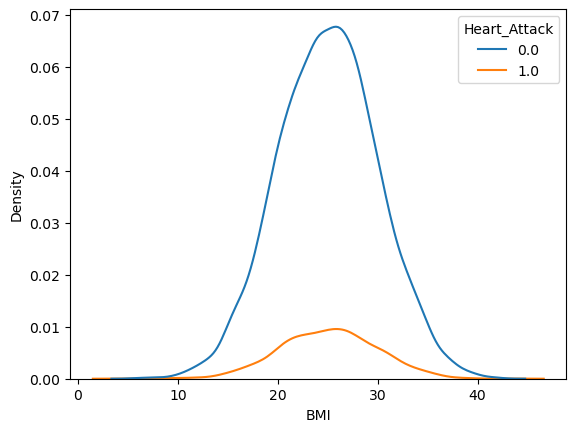

Heart_Rate


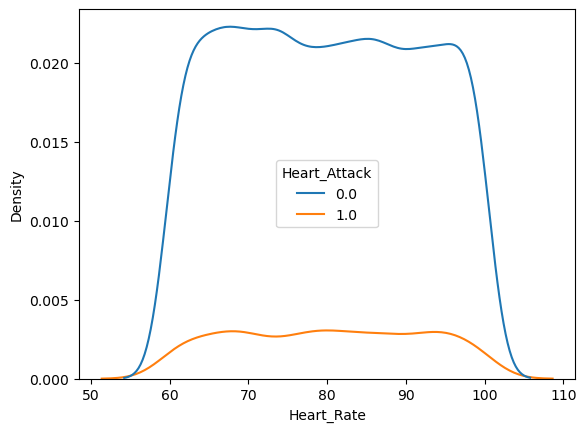

Stress_Level


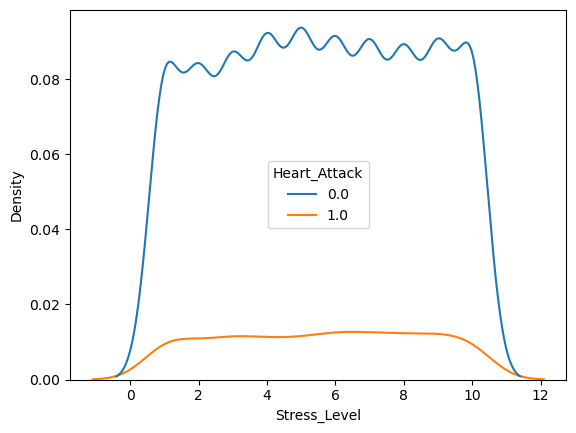

Heart_Attack


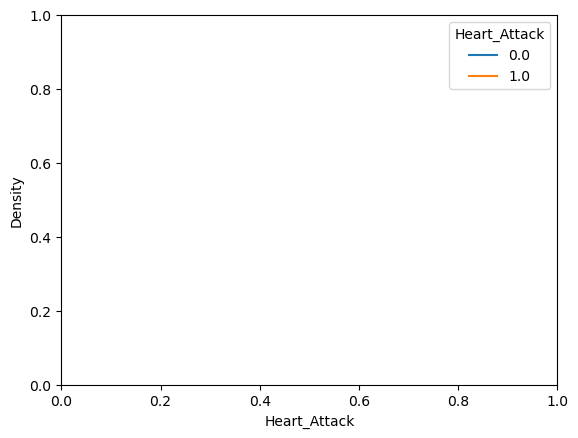

Angina


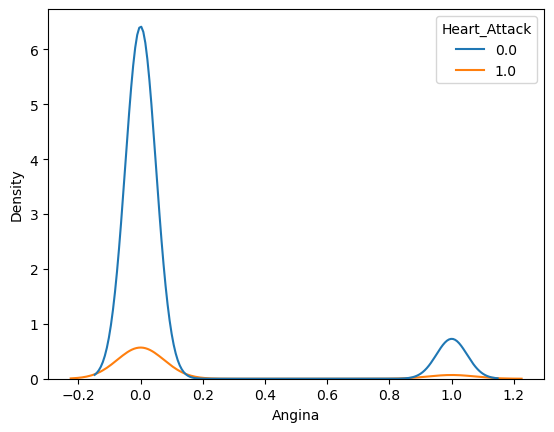

Sleep_Hours


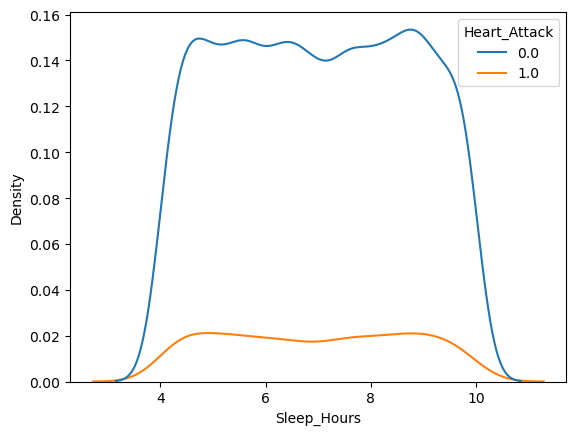

Health_Awareness


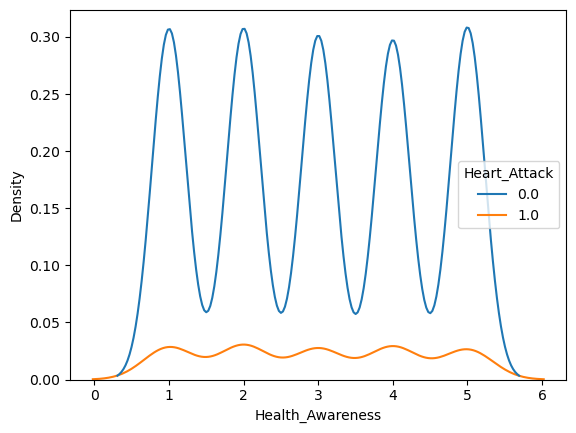

Daily_Water_Intake


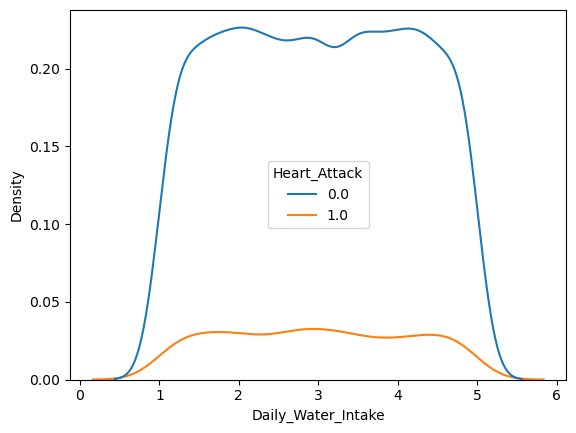

Mental_Health


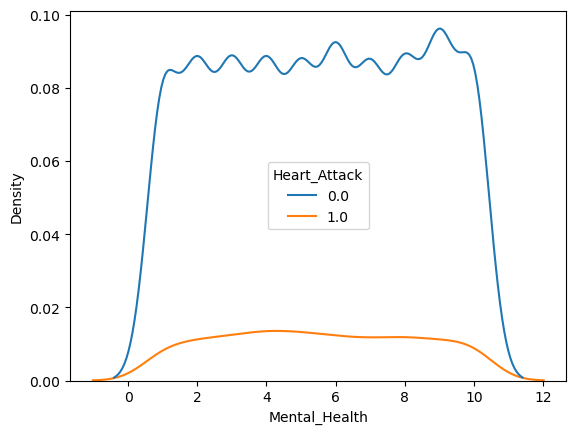

In [52]:
for i in data.select_dtypes(exclude="object"):
    print(i)
    sns.kdeplot(x=data[i],hue=data.Heart_Attack)
    plt.show()

In [53]:
# log(odds)=B1.x1 +b2.x2...bnxn +b0  (log(odds)=y/1-y)
#logistic regression

In [54]:
smt=SMOTE()

In [55]:
xtrain,ytrain = smt.fit_resample(xtrain,ytrain)

In [56]:
xtrain_c=sm.add_constant(xtrain)
xtest_c= sm.add_constant(xtest)

In [57]:
xtrain_c.head(1)

,const,Age,Blood_Pressure,Cholesterol,BMI,Heart_Rate,Exercise_Level,Smoking,Alcohol_Consumption,Diabetes,Family_History,Stress_Level,Angina,Heart_Disease_History,Diet,Sleep_Hours,Income_Level,Physical_Activity,Urban_Rural,Medication,Health_Awareness,Daily_Water_Intake,Mental_Health,Obesity,Female,Male,Other,Rural,Suburban,Urban,Employed,Retired,Student,Unemployed,Higher,Primary,Secondary,Divorced,Married,Single,Widowed
0,1.0,48,128.5,273.4,18.8,64.0,3,1,2,0,0,8.0,0,0,1,6.6,3,1,1,0,4.0,1.2,5.0,1,0,1,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0


In [58]:
model1=sm.Logit(ytrain,xtrain_c).fit()

         Current function value: 0.211273
         Iterations: 35


In [59]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           Heart_Attack   No. Observations:                14066
Model:                          Logit   Df Residuals:                    14025
Method:                           MLE   Df Model:                           40
Date:                Mon, 08 Dec 2025   Pseudo R-squ.:                  0.6952
Time:                        09:38:03   Log-Likelihood:                -2971.8
converged:                      False   LL-Null:                       -9749.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   119.8190   1.62e+06    7.4e-05      1.000   -3.17e+06    3.17e+06
Age                      -0.0015      0.002     -0.633      0.527      -0.006       0.003
Blood_Pressure           -0.0018      0.002     -0.792      0.429      -0.006       0.003
Cholesterol              -0.0005      0.001     -0.655      0.512      -0.002       0.001
BMI                       0.0092      0.007      1.331      0.183      -0.004       0.023
Heart_Rate                0.0018      0.003      0.612      0.540      -0.004       0.007
Exercise_Level           -0.0567      0.049     -1.165      0.244      -0.152       0.039
Smoking                  -0.0153      0.075     -0.205      0.838      -0.162       0.131
Alcohol_Consumption       0.0500      0.111      0.450      0.653      -0.168       0.268
Diabetes                 -0.1744      0.101     -1.724      0.085      -0.373       0.024
Family_History            0.0105      0.070      0.151      0.880      -0.126       0.147
Stress_Level              0.0091      0.012      0.764      0.445      -0.014       0.032
Angina                   -0.0071      0.112     -0.063      0.950      -0.227       0.213
Heart_Disease_History    -0.2174      0.104     -2.095      0.036      -0.421      -0.014
Diet                      0.0400      0.041      0.969      0.333      -0.041       0.121
Sleep_Hours              -0.0108      0.020     -0.549      0.583      -0.049       0.028
Income_Level             -0.0125      0.045     -0.276      0.783      -0.102       0.077
Physical_Activity        -0.0556      0.049     -1.137      0.256      -0.151       0.040
Urban_Rural              -0.0232      0.070     -0.333      0.739      -0.159       0.113
Medication                0.0003      0.086      0.004      0.997      -0.168       0.168
Health_Awareness          0.0021      0.024      0.089      0.929      -0.045       0.050
Daily_Water_Intake       -0.0423      0.030     -1.425      0.154      -0.100       0.016
Mental_Health            -0.0033      0.012     -0.278      0.781      -0.027       0.020
Obesity                  -0.2170      0.089     -2.432      0.015      -0.392      -0.042
Female                  -21.4096   2645.797     -0.008      0.994   -5207.076    5164.257
Male                    -21.4758   2645.797     -0.008      0.994   -5207.142    5164.191
Other                   -21.5254   2645.797     -0.008      0.994   -5207.192    5164.141
Rural                   -22.5272   3257.168     -0.007      0.994   -6406.460    6361.405
Suburban                -22.4953   3257.168     -0.007      0.994   -6406.428    6361.437
Urban                   -22.6315   3257.168     -0.007      0.994   -6406.564    6361.301
Employed                -18.1600    336.100     -0.054      0.957    -676.904     640.584
Retired                 -18.1631    336.100     -0.054      0.957    -676.907     640.581
Student                 -18.1733    336.100     -0.054      0.957    -676.918     640.571
U

In [60]:
model1.predict(xtest_c)

8133     0.154237
32909    0.087514
45920    0.123873
6703     0.132749
20737    0.120667
           ...   
35424    0.138510
34481    0.093885
40997    0.120993
49301    0.132531
5348     0.103639
Length: 1996, dtype: float64

In [61]:
l_xtest=[1 if x>0.5 else 0 for x in model1.predict(xtest_c)]

In [62]:
from sklearn.metrics import classification_report,confusion_matrix

In [63]:
print(classification_report(ytest,l_xtest))

              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94      1756
         1.0       0.00      0.00      0.00       240

    accuracy                           0.88      1996
   macro avg       0.44      0.50      0.47      1996
weighted avg       0.77      0.88      0.82      1996



<Axes: >

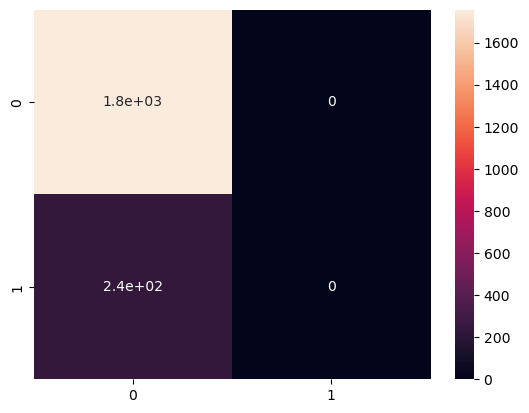

In [64]:
sns.heatmap(confusion_matrix(ytest,l_xtest),annot=True)

In [65]:
from sklearn.neighbors import KNeighborsClassifier

In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
s=StandardScaler()

In [68]:
for i in xtrain.columns:
    xtrain[i]=s.fit_transform(xtrain[[i]])
    xtest[i]=s.transform(xtest[[i]])

In [69]:
k=KNeighborsClassifier(n_neighbors=5)

In [70]:
k.fit(xtrain,ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [71]:
print(classification_report(ytest,k.predict(xtest)))

              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89      1756
         1.0       0.10      0.08      0.09       240

    accuracy                           0.80      1996
   macro avg       0.49      0.49      0.49      1996
weighted avg       0.79      0.80      0.79      1996



<Axes: >

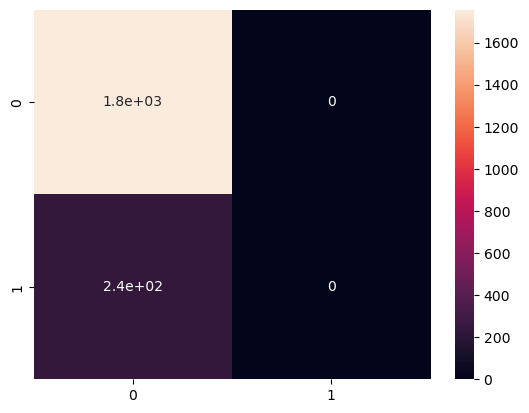

In [72]:
sns.heatmap(confusion_matrix(ytest,l_xtest),annot=True)

In [73]:
from sklearn.model_selection import cross_val_score

In [74]:
k_neighbour = [i for i in range(1,22,2)]
cross_val=[]

In [75]:
for i in k_neighbour:
    knn = KNeighborsClassifier(n_neighbors=i)
    cross_val.append(np.mean(cross_val_score(estimator=knn,X=xtrain,y=ytrain,cv=5,n_jobs=-1)))
    

In [76]:
cross_val

[np.float64(0.8828447271539313),
 np.float64(0.9001224389453878),
 np.float64(0.9026822618409653),
 np.float64(0.9023279822511533),
 np.float64(0.898346973173339),
 np.float64(0.892802252512765),
 np.float64(0.8898876699737309),
 np.float64(0.8866887188151467),
 np.float64(0.8826365102020242),
 np.float64(0.8795086069828603),
 np.float64(0.8762384310229867)]

In [77]:
np.argmax(cross_val)

np.int64(2)

In [78]:
k_neighbour[9]

19

In [79]:
knn_model2=KNeighborsClassifier(n_neighbors=k_neighbour[9])


In [80]:
knn_model2.fit(xtrain,ytrain)

,n_neighbors,19
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [81]:
print(classification_report(ytest,knn_model2.predict(xtest)))

              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      1756
         1.0       0.11      0.11      0.11       240

    accuracy                           0.79      1996
   macro avg       0.50      0.50      0.50      1996
weighted avg       0.79      0.79      0.79      1996



In [82]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [83]:
dt = DecisionTreeClassifier(max_depth=3)

In [84]:
dt.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
print(classification_report(ytrain,dt.predict(xtrain)))

              precision    recall  f1-score   support

         0.0       0.75      0.86      0.80      7033
         1.0       0.83      0.71      0.76      7033

    accuracy                           0.78     14066
   macro avg       0.79      0.78      0.78     14066
weighted avg       0.79      0.78      0.78     14066



In [86]:
print(classification_report(ytest,dt.predict(xtest)))

              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86      1756
         1.0       0.10      0.13      0.11       240

    accuracy                           0.76      1996
   macro avg       0.49      0.49      0.49      1996
weighted avg       0.78      0.76      0.77      1996



[Text(0.5, 0.875, 'x[28] <= 0.272\ngini = 0.5\nsamples = 14066\nvalue = [7033, 7033]'),
 Text(0.25, 0.625, 'x[26] <= 0.675\ngini = 0.48\nsamples = 8881\nvalue = [3543, 5338]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[27] <= 1.073\ngini = 0.373\nsamples = 5782\nvalue = [1434, 4348]'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 3895\nvalue = [0, 3895]'),
 Text(0.1875, 0.125, 'gini = 0.365\nsamples = 1887\nvalue = [1434, 453]'),
 Text(0.375, 0.375, 'x[24] <= 0.239\ngini = 0.435\nsamples = 3099\nvalue = [2109, 990]'),
 Text(0.3125, 0.125, 'gini = 0.48\nsamples = 1765\nvalue = [1061, 704]'),
 Text(0.4375, 0.125, 'gini = 0.337\nsamples = 1334\nvalue = [1048, 286]'),
 Text(0.75, 0.625, 'x[33] <= 0.725\ngini = 0.44\nsamples = 5185\nvalue = [3490, 1695]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[35] <= 0.431\ngini = 0.472\nsamples = 3944\nvalue = [2436, 1508]'),
 Text(0.5625, 0.125, 'gini = 0.499\nsamples = 2086\nvalue = [1008, 1078]'),
 Text(0.6875, 0.125, 'gini = 0

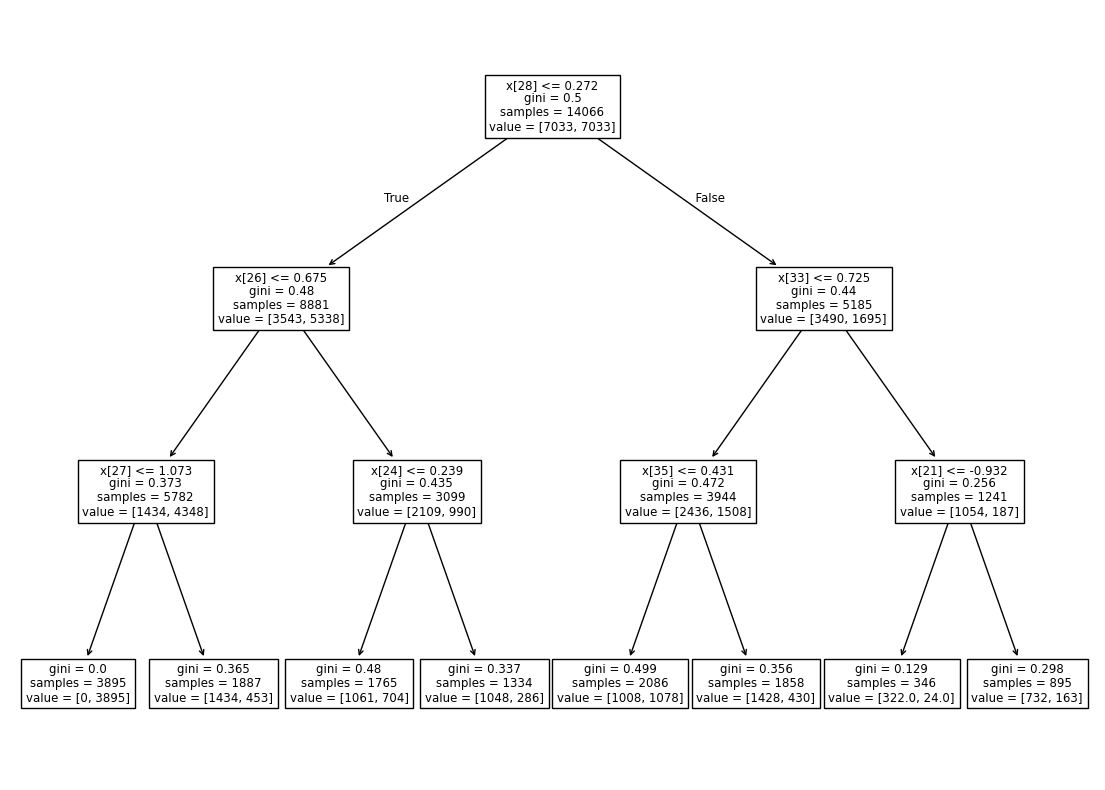

In [87]:
plt.figure(figsize=[14,10])
plot_tree(dt)



creating confusion matrix

<Axes: >

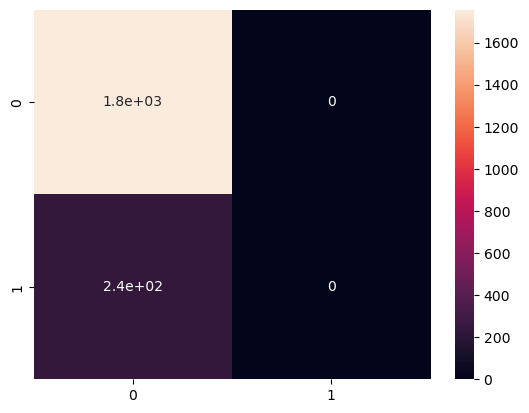

In [88]:
sns.heatmap(confusion_matrix(ytest,l_xtest),annot=True)

In [89]:
y_pred = dt.predict(xtest)  


In [90]:
cm = confusion_matrix(ytest, y_pred)  # Compare actual vs. predicted
print(cm)


[[1485  271]
 [ 209   31]]


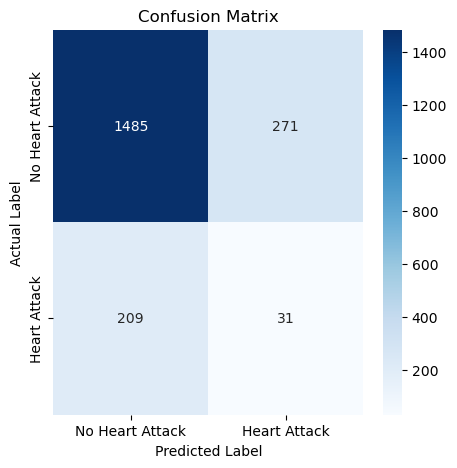

In [91]:
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Heart Attack", "Heart Attack"], yticklabels=["No Heart Attack", "Heart Attack"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


In [92]:

print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86      1756
         1.0       0.10      0.13      0.11       240

    accuracy                           0.76      1996
   macro avg       0.49      0.49      0.49      1996
weighted avg       0.78      0.76      0.77      1996



SVM,GRIDSEARCHCV,RANDOM FOREST, OVERsampling

In [93]:
data["Heart_Attack"].value_counts(normalize=True)*100

Heart_Attack
0.0    88.066132
1.0    11.933868
Name: proportion, dtype: float64

In [94]:
DecisionTreeClassifier()

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [95]:
from sklearn.model_selection import GridSearchCV

In [96]:
param_values={"max_depth":[i for i in range(2,5)],
              "min_samples_split":[i for i in range(2,5)]}

In [97]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(),
                    param_grid=param_values,
                    scoring="precision",
                    n_jobs=-1)

In [98]:
grid.fit(xtrain,ytrain)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [99]:
grid.best_params_

{'max_depth': 4, 'min_samples_split': 2}

In [100]:
dt2=DecisionTreeClassifier(max_depth=4,min_samples_leaf=2)

In [101]:
dt2.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [102]:
from sklearn.svm import SVC

In [103]:
svc_model= SVC()

In [104]:
svc_model.fit(xtrain,ytrain)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [105]:
param_values_Svc={'kernel':["linear","poly","rbf","sigmoid"]}

In [106]:
grid2=GridSearchCV(
    estimator=SVC(),param_grid=param_values_Svc,
    scoring="precision",n_jobs=-1
)

In [107]:
grid2.fit(xtrain,ytrain)

,estimator,SVC()
,param_grid,"{'kernel': ['linear', 'poly', ...]}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [108]:
grid2.best_params_

{'kernel': 'linear'}

In [109]:
svc_model2=SVC(kernel="linear")

In [110]:
svc_model2.fit(xtrain,ytrain)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [111]:
from sklearn.ensemble import RandomForestClassifier

In [112]:
rf=RandomForestClassifier()

In [113]:
rf.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [114]:
importance=pd.DataFrame(rf.feature_importances_,index=xtrain.columns,columns=["Values"])

In [115]:
importance.sort_values(by="Values",ascending=False)

,Values
Rural,0.046065
Health_Awareness,0.045950
Urban,0.044317
Secondary,0.041499
Primary,0.040993
Suburban,0.039625
Cholesterol,0.038884
Higher,0.037657
Blood_Pressure,0.034026
Single,0.032757
